## Первоначальное тиранье датасета



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import sklearn
import joblib


In [3]:
#!wget https://disk.yandex.ru/d/XQ8yJ-gUebodbA
#  странно не прокатывает

In [20]:
!unzip /content/train_data.zip


Archive:  /content/train_data.zip
replace realty_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [5]:
df=pd.read_csv('/content/realty_data.csv')
df.head(3)

,product_name,period,price,postcode,address_name,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,description,source
0,"3-комнатная, 137 м²",NaN,63000000,127473.0,"2-й Щемиловский переулок, 5а",55.778894,37.608844,Квартира,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,Просторная квартира свободной планировки с пан...,ЦИАН
1,"Студия, 16,7 м²",NaN,3250000,108815.0,"Харлампиева, 46",55.551025,37.313054,Квартира,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,ВНИМАНИЕ! ОЧЕНЬ ПРИВЛЕКАТЕЛЬНОЕ ПРЕ...,Домклик
2,"3-комнатная, 76 м²",NaN,16004680,NaN,"ЖК Прокшино, 8 к4",55.594802,37.431264,Квартира,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,"Apт.1684018. 0,01% - гибкая ипотека! Воспользу...",Яндекс.Недвижимость


In [6]:
df.shape

(98822, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98822 entries, 0 to 98821
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  98822 non-null  object 
 1   period        0 non-null      float64
 2   price         98822 non-null  int64  
 3   postcode      93675 non-null  float64
 4   address_name  98821 non-null  object 
 5   lat           98822 non-null  float64
 6   lon           98822 non-null  float64
 7   object_type   98822 non-null  object 
 8   total_square  98822 non-null  float64
 9   rooms         94840 non-null  float64
 10  floor         98822 non-null  float64
 11  city          91928 non-null  object 
 12  settlement    6894 non-null   object 
 13  district      75111 non-null  object 
 14  area          19498 non-null  object 
 15  description   98573 non-null  object 
 16  source        98822 non-null  object 
dtypes: float64(7), int64(1), object(9)
memory usage: 12.8+ MB


In [8]:
del df['description']
del df['source']
del df['product_name']
del df['address_name']
del df['period']
df.head(3)

,price,postcode,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area
0,63000000,127473.0,55.778894,37.608844,Квартира,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN
1,3250000,108815.0,55.551025,37.313054,Квартира,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN
2,16004680,NaN,55.594802,37.431264,Квартира,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN


In [9]:
df['price_mln']=df['price']/1e6
df.head(3)

,price,postcode,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,price_mln
0,63000000,127473.0,55.778894,37.608844,Квартира,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,63.00000
1,3250000,108815.0,55.551025,37.313054,Квартира,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,3.25000
2,16004680,NaN,55.594802,37.431264,Квартира,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,16.00468


In [10]:
df.describe()

,price,postcode,lat,lon,total_square,rooms,floor,price_mln
count,9.882200e+04,93675.000000,98822.000000,98822.000000,98822.000000,94840.000000,98822.000000,98822.000000
mean,2.512122e+07,124503.585119,55.742691,37.586404,66.092176,2.197427,9.905274,25.121224
std,3.607234e+07,11956.742109,0.107044,0.169843,48.816204,1.038628,8.219180,36.072336
min,1.900000e+06,101000.000000,55.468426,37.136489,8.000000,1.000000,1.000000,1.900000
25%,1.050000e+07,115516.000000,55.673101,37.471611,40.100000,1.000000,4.000000,10.500000
50%,1.516713e+07,123154.000000,55.745474,37.569365,56.400000,2.000000,8.000000,15.167126
75%,2.500000e+07,140003.000000,55.817697,37.689568,75.700000,3.000000,14.000000,25.000000
max,1.155219e+09,143989.000000,56.028824,38.122467,2070.000000,15.000000,66.000000,1155.219000


In [11]:
!pip install plotly

In [12]:
import plotly.express as px
#fig = px.scatter_geo(df, lat=df['lat'], lon=df['lon'], projection="natural earth")
fig = px.scatter_mapbox(df,lat=df['lat'],lon=df['lon'], text='city', zoom=9, center=dict(lat=55.7558, lon=37.6173))
# Настройка макета
'''fig.update_layout(
    title="График координат на карте",
    geo=dict(
        showland=True,
        landcolor="lightgreen",
        oceancolor="lightblue",
        showocean=True,
        lakecolor="blue"
    )
)'''
fig.update_layout(
    title="Точки на карте Москвы",
    mapbox_style="open-street-map"  # Используем стиль OpenStreetMap
)

# Показать график
fig.show()


In [13]:
df2=df #на всякий случай
del df2['price']

In [14]:
df2['price_mln']=round(df2['price_mln'],2)
df2.head(3)

,postcode,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,price_mln
0,127473.0,55.778894,37.608844,Квартира,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,63.00
1,108815.0,55.551025,37.313054,Квартира,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,3.25
2,NaN,55.594802,37.431264,Квартира,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,16.00


In [15]:
for i in df2: #число групп, видно что  obect type тоже не нужен
  print(f'столбец {i} группы {len(df2.groupby(i).groups)}')

столбец postcode группы 657
столбец lat группы 21811
столбец lon группы 22060
столбец object_type группы 1
столбец total_square группы 5357
столбец rooms группы 15
столбец floor группы 61
столбец city группы 21
столбец settlement группы 46
столбец district группы 130
столбец area группы 269
столбец price_mln группы 6870


In [16]:
del df2['object_type']


In [17]:
import numpy as np


In [18]:
df2.replace('', np.nan, inplace=True)
df2.head(3)

,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,area,price_mln
0,127473.0,55.778894,37.608844,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,63.00
1,108815.0,55.551025,37.313054,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,3.25
2,NaN,55.594802,37.431264,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,16.00


In [19]:
df2.to_csv('mylocaldata.csv')

## Просто подмать

In [21]:
df2=pd.read_csv('/content/mylocaldata.csv')

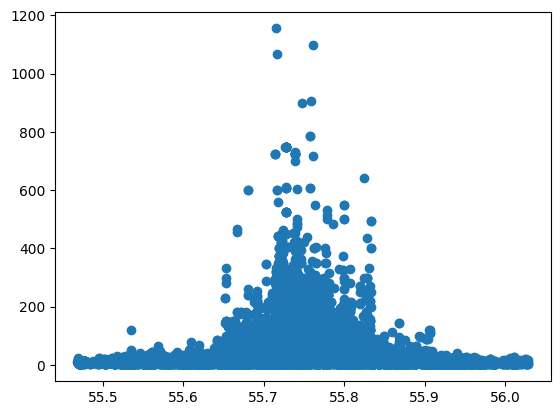

In [22]:
from matplotlib import pyplot as plt

plt.scatter(df2['lat'],df2['price_mln'])

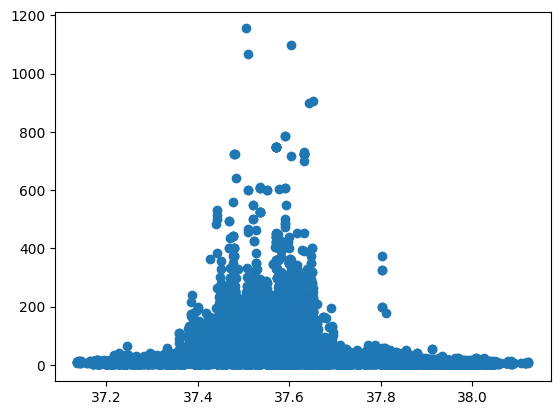

In [23]:
from matplotlib import pyplot as plt

plt.scatter(df2['lon'],df2['price_mln'])

In [24]:
city_cat=df2['city'].astype('category')
print(city_cat)

0        Москва
1        Москва
2        Москва
3        Москва
4        Москва
          ...  
98817    Москва
98818    Москва
98819    Москва
98820    Москва
98821    Москва
Name: city, Length: 98822, dtype: category
Categories (21, object): ['Балашиха', 'Видное', 'Дзержинский', 'Долгопрудный', ..., 'Реутов', 'Химки',
                          'Щербинка', 'Щёлково']


In [25]:
settlement_cat=df2['settlement'].astype('category')
print(settlement_cat)

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
98817    NaN
98818    NaN
98819    NaN
98820    NaN
98821    NaN
Name: settlement, Length: 98822, dtype: category
Categories (46, object): ['д. Аристово', 'д. Болтино', 'д. Большие Жеребцы', 'д. Глухово', ...,
                          'с. Молоково', 'с. Немчиновка', 'с. Николо-Урюпино', 'с. Ромашково']


In [26]:
district_cat=df2['district'].astype('category')
print(district_cat)

0                  Тверской район
1        Филимонковское поселение
2             Сосенское поселение
3             Сосенское поселение
4            Фили-Давыдково район
                   ...           
98817           Головинский район
98818             Мещанский район
98819       Чертаново Южное район
98820          Текстильщики район
98821          Южнопортовый район
Name: district, Length: 98822, dtype: category
Categories (130, object): ['Академический район', 'Алексеевский район', 'Алтуфьевский район',
                           'Арбат район', ..., 'Южнопортовый район', 'Якиманка район',
                           'Ярославский район', 'Ясенево район']


In [27]:

df2.head(3)

,Unnamed: 0,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,area,price_mln
0,0,127473.0,55.778894,37.608844,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,63.00
1,1,108815.0,55.551025,37.313054,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,3.25
2,2,NaN,55.594802,37.431264,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,16.00


In [28]:
del df2['Unnamed: 0']
df2.head(3)

,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,area,price_mln
0,127473.0,55.778894,37.608844,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,63.00
1,108815.0,55.551025,37.313054,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,3.25
2,NaN,55.594802,37.431264,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,16.00


<Axes: >

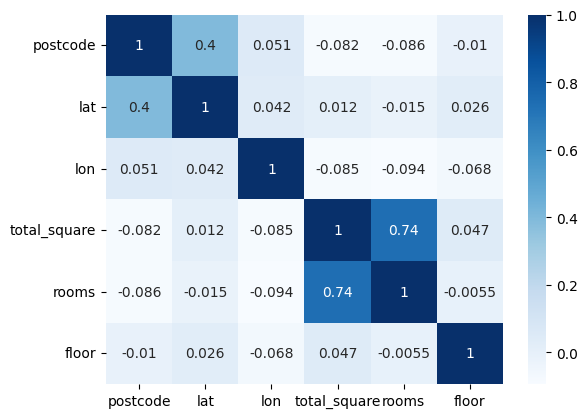

In [29]:
import seaborn as sb
corr = df2[['postcode','lat','lon', 'total_square', 'rooms', 'floor', ]].corr()
sb.heatmap(corr, cmap="Blues", annot=True)

In [30]:
df2.to_csv('mylocaldata2.csv')

##  А теперь СциКит

In [ ]:
# Это было просто теперь поговоим про модели

In [31]:
import pandas as pd
import numpy as np
df3=pd.read_csv('/content/mylocaldata2.csv')

In [32]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [33]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98822 entries, 0 to 98821
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    98822 non-null  int64  
 1   postcode      93675 non-null  float64
 2   lat           98822 non-null  float64
 3   lon           98822 non-null  float64
 4   total_square  98822 non-null  float64
 5   rooms         94840 non-null  float64
 6   floor         98822 non-null  float64
 7   city          91928 non-null  object 
 8   settlement    6894 non-null   object 
 9   district      75111 non-null  object 
 10  area          19498 non-null  object 
 11  price_mln     98822 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 9.0+ MB


In [34]:
#df3.dropna(inplace=True)
df3.head(3)
#df3.drop_duplicates(inplace=True)

,Unnamed: 0,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,area,price_mln
0,0,127473.0,55.778894,37.608844,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,63.00
1,1,108815.0,55.551025,37.313054,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,3.25
2,2,NaN,55.594802,37.431264,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,16.00


In [35]:
del df3['Unnamed: 0']
del df3['area']
df3

,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,price_mln
0,127473.0,55.778894,37.608844,137.0,3.0,6.0,Москва,NaN,Тверской район,63.00
1,108815.0,55.551025,37.313054,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,3.25
2,NaN,55.594802,37.431264,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,16.00
3,NaN,55.594332,37.428099,24.0,1.0,10.0,Москва,NaN,Сосенское поселение,7.84
4,121352.0,55.721097,37.464342,126.0,3.0,16.0,Москва,NaN,Фили-Давыдково район,120.00
...,...,...,...,...,...,...,...,...,...,...
98817,125212.0,55.842935,37.487680,42.0,2.0,8.0,Москва,NaN,Головинский район,12.18
98818,129090.0,55.777354,37.621747,63.5,2.0,3.0,Москва,NaN,Мещанский район,34.92
98819,117534.0,55.602124,37.591573,34.4,1.0,3.0,Москва,NaN,Чертаново Южное район,10.00
98820,109518.0,55.719431,37.724875,56.0,3.0,11.0,Москва,NaN,Текстильщики район,16.00


In [36]:
df3['settlement'] = df3['settlement'].fillna(df3['city'])
df3

,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,price_mln
0,127473.0,55.778894,37.608844,137.0,3.0,6.0,Москва,Москва,Тверской район,63.00
1,108815.0,55.551025,37.313054,16.7,NaN,1.0,Москва,Москва,Филимонковское поселение,3.25
2,NaN,55.594802,37.431264,76.0,3.0,6.0,Москва,Москва,Сосенское поселение,16.00
3,NaN,55.594332,37.428099,24.0,1.0,10.0,Москва,Москва,Сосенское поселение,7.84
4,121352.0,55.721097,37.464342,126.0,3.0,16.0,Москва,Москва,Фили-Давыдково район,120.00
...,...,...,...,...,...,...,...,...,...,...
98817,125212.0,55.842935,37.487680,42.0,2.0,8.0,Москва,Москва,Головинский район,12.18
98818,129090.0,55.777354,37.621747,63.5,2.0,3.0,Москва,Москва,Мещанский район,34.92
98819,117534.0,55.602124,37.591573,34.4,1.0,3.0,Москва,Москва,Чертаново Южное район,10.00
98820,109518.0,55.719431,37.724875,56.0,3.0,11.0,Москва,Москва,Текстильщики район,16.00


In [37]:
df3['rooms'] = df3['rooms'].fillna(round(df3['total_square']/18.0))
df3

,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,price_mln
0,127473.0,55.778894,37.608844,137.0,3.0,6.0,Москва,Москва,Тверской район,63.00
1,108815.0,55.551025,37.313054,16.7,1.0,1.0,Москва,Москва,Филимонковское поселение,3.25
2,NaN,55.594802,37.431264,76.0,3.0,6.0,Москва,Москва,Сосенское поселение,16.00
3,NaN,55.594332,37.428099,24.0,1.0,10.0,Москва,Москва,Сосенское поселение,7.84
4,121352.0,55.721097,37.464342,126.0,3.0,16.0,Москва,Москва,Фили-Давыдково район,120.00
...,...,...,...,...,...,...,...,...,...,...
98817,125212.0,55.842935,37.487680,42.0,2.0,8.0,Москва,Москва,Головинский район,12.18
98818,129090.0,55.777354,37.621747,63.5,2.0,3.0,Москва,Москва,Мещанский район,34.92
98819,117534.0,55.602124,37.591573,34.4,1.0,3.0,Москва,Москва,Чертаново Южное район,10.00
98820,109518.0,55.719431,37.724875,56.0,3.0,11.0,Москва,Москва,Текстильщики район,16.00


In [38]:
categorical_features = ['object_type', 'city', 'settlement', 'district','postcode']
numerical_features = ['lat', 'lon', 'total_square', 'rooms', 'floor']

In [39]:
scaler = StandardScaler() #попробуем отмасштаюбировать, вдруг что-то и получится
df3[numerical_features] = scaler.fit_transform(df3[numerical_features])

In [ ]:
'''encoder = OneHotEncoder()
encoded_columns = encoder.fit_transform(df3[categorical_features])
encoder.fit_transform(df3[categorical_features])
encoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(categorical_features))'''

'encoder = OneHotEncoder()\nencoded_columns = encoder.fit_transform(df3[categorical_features])\nencoder.fit_transform(df3[categorical_features])\nencoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(categorical_features))'

In [ ]:
#первый вариант
'''preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
'''

"preprocessor = ColumnTransformer(\n    transformers=[\n        ('num', StandardScaler(), numerical_features),\n        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)\n    ])\n"

In [40]:
df3

,postcode,lat,lon,total_square,rooms,floor,city,settlement,district,price_mln
0,127473.0,0.338212,0.132124,1.452554,0.687191,-0.475144,Москва,Москва,Тверской район,63.00
1,108815.0,-1.790539,-1.609433,-1.011804,-0.999166,-1.083480,Москва,Москва,Филимонковское поселение,3.25
2,NaN,-1.381575,-0.913434,0.202963,0.687191,-0.475144,Москва,Москва,Сосенское поселение,16.00
3,NaN,-1.385966,-0.932069,-0.862263,-0.999166,0.011525,Москва,Москва,Сосенское поселение,7.84
4,121352.0,-0.201728,-0.718677,1.227218,0.687191,0.741529,Москва,Москва,Фили-Давыдково район,120.00
...,...,...,...,...,...,...,...,...,...,...
98817,125212.0,0.936482,-0.581267,-0.493531,-0.155987,-0.231809,Москва,Москва,Головинский район,12.18
98818,129090.0,0.323825,0.208095,-0.053101,-0.155987,-0.840146,Москва,Москва,Мещанский район,34.92
98819,117534.0,-1.313173,0.030436,-0.649218,-0.999166,-0.840146,Москва,Москва,Чертаново Южное район,10.00
98820,109518.0,-0.217291,0.815293,-0.206739,0.687191,0.133192,Москва,Москва,Текстильщики район,16.00


In [41]:
try:
  del df3['postcode']
  del df3['city']
  del df3['settlement']
  del df3['district']
except:
  pass

In [42]:

from sklearn.model_selection import train_test_split # поделим
X = df3.drop('price_mln', axis=1)
y = df3['price_mln']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:
X.head(3)

,lat,lon,total_square,rooms,floor
0,0.338212,0.132124,1.452554,0.687191,-0.475144
1,-1.790539,-1.609433,-1.011804,-0.999166,-1.083480
2,-1.381575,-0.913434,0.202963,0.687191,-0.475144


In [44]:
y.head(3)

,price_mln
0,63.00
1,3.25
2,16.00


In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [46]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 358.61914728147167


In [47]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

pred = model.predict(X_test)

print(round(mean_squared_error(y_test, pred),2)) #MSE
print(round(mean_squared_error(y_test, pred)**0.5,2)) #RMSE
print(round(root_mean_squared_error(y_test, pred),2)) #RMSE
print(round(r2_score(y_test, pred),2)) #R2
print(round(mean_absolute_error(y_test, pred),2)) #MAE

358.62
18.94
18.94
0.73
9.62


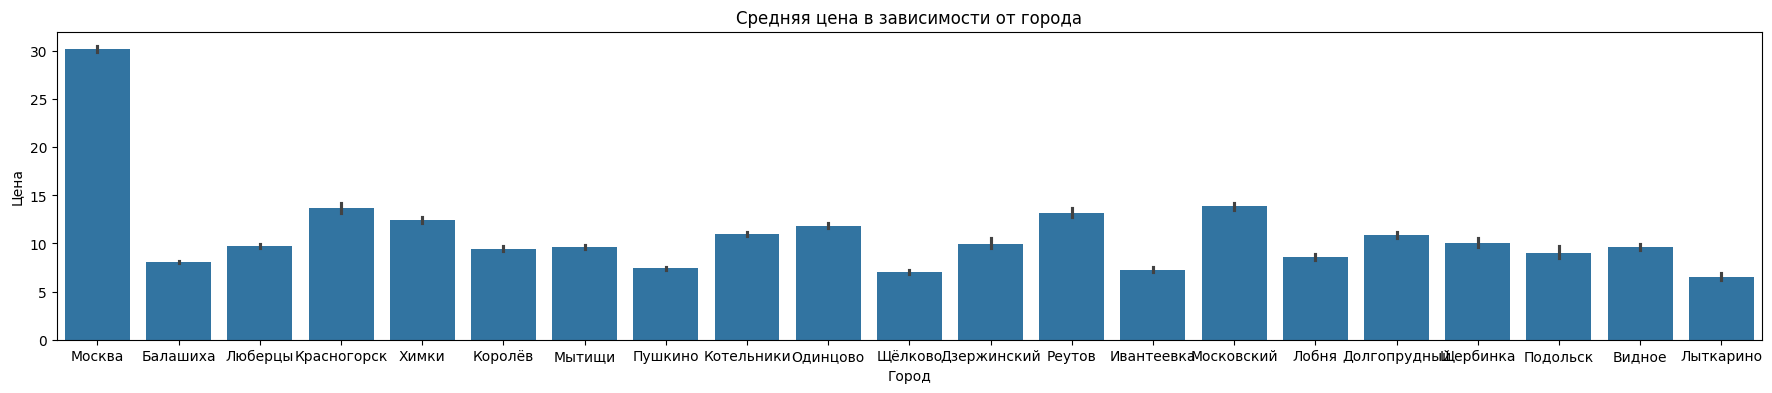

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 4))
sns.barplot(x='city', y='price_mln', data=df2)

plt.title('Средняя цена в зависимости от города')
plt.xlabel('Город')
plt.ylabel('Цена')

plt.show()

In [49]:
from sklearn.model_selection import train_test_split # поделим и если оставить только координаты прям странно
df4=df3[['lat','lon','price_mln']]
X = df4.drop('price_mln', axis=1)
y = df4['price_mln']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

In [51]:
pred = model.predict(X_test)

print(round(mean_squared_error(y_test, pred),2)) #MSE
print(round(mean_squared_error(y_test, pred)**0.5,2)) #RMSE
print(round(root_mean_squared_error(y_test, pred),2)) #RMSE
print(round(r2_score(y_test, pred),2)) #R2
print(round(mean_absolute_error(y_test, pred),2)) #MAE

1330.38
36.47
36.47
0.01
17.61


In [52]:
#потестим без координат
from sklearn.model_selection import train_test_split
df4=df3[['total_square', 'rooms', 'floor', 'price_mln']]
X = df4.drop('price_mln', axis=1)
y = df4['price_mln']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
model = LinearRegression() #странно коорждинаты показывают хорошую корреляцию с ценой
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
pred = model.predict(X_test)

print(round(mean_squared_error(y_test, pred),2)) #MSE
print(round(mean_squared_error(y_test, pred)**0.5,2)) #RMSE
print(round(root_mean_squared_error(y_test, pred),2)) #RMSE
print(round(r2_score(y_test, pred),2)) #R2
print(round(mean_absolute_error(y_test, pred),2)) #MAE

358.8
18.94
18.94
0.73
9.65


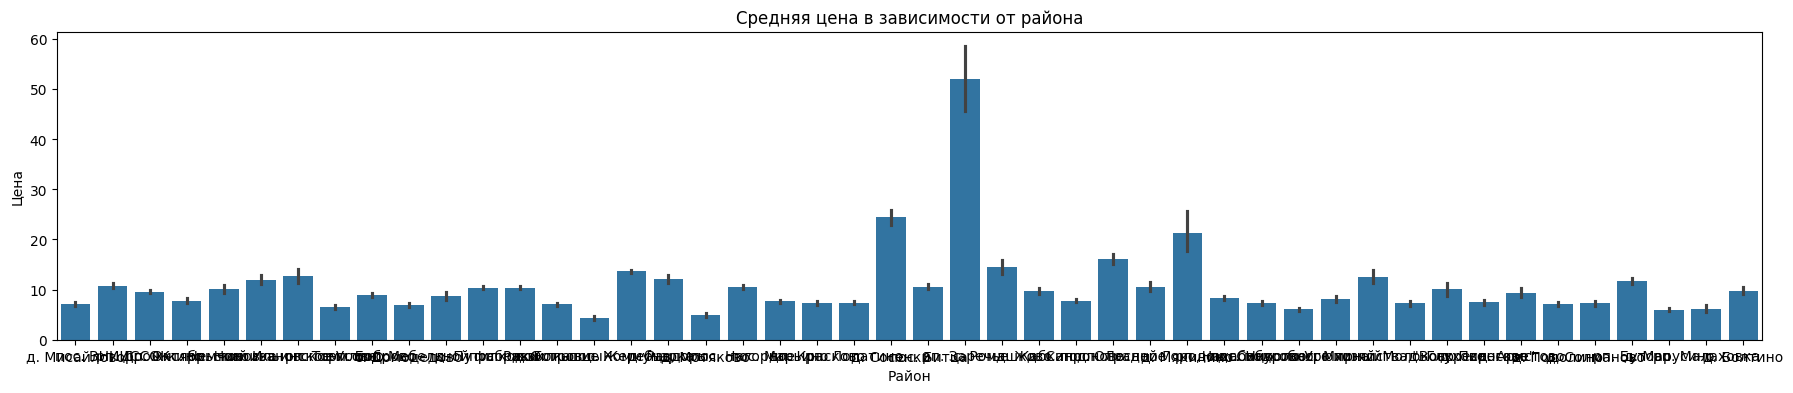

In [54]:
plt.figure(figsize=(22, 4))#много параметров пока не очевидно
sns.barplot(x='settlement', y='price_mln', data=df2)

plt.title('Средняя цена в зависимости от района')
plt.xlabel('Район')
plt.ylabel('Цена')

plt.show()

In [55]:
#распарсим города
df_encoded = pd.get_dummies(df2, columns=['city'], drop_first = True, dtype = int)
df_encoded=df_encoded.drop(['postcode', 'settlement', 'district', 'area'], axis=1).dropna()
df_encoded.head(3)

,lat,lon,total_square,rooms,floor,price_mln,city_Видное,city_Дзержинский,city_Долгопрудный,city_Ивантеевка,...,city_Москва,city_Московский,city_Мытищи,city_Одинцово,city_Подольск,city_Пушкино,city_Реутов,city_Химки,city_Щербинка,city_Щёлково
0,55.778894,37.608844,137.0,3.0,6.0,63.00,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,55.594802,37.431264,76.0,3.0,6.0,16.00,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,55.594332,37.428099,24.0,1.0,10.0,7.84,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [56]:
df_encoded.shape

(94840, 26)

In [57]:
X_enc = df_encoded.drop(['price_mln'], axis=1)
y_enc = df_encoded['price_mln']

In [58]:
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_enc, y_enc, test_size=0.25, random_state=42)

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_enc, y_train_enc)

LinearRegression()

In [60]:
pred_enc = model.predict(X_test_enc)

In [61]:
round(r2_score(y_test_enc, pred_enc),2) # а не возрасло

0.73

In [62]:
joblib.dump(model, 'linearreg_model.joblib')

['linearreg_model.joblib']

In [63]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 85.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [65]:
from sklearn.model_selection import train_test_split

In [66]:
from catboost import CatBoostRegressor # не завелся котик
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Определяем целевую переменную и признаки
X = df.drop('price_mln', axis=1)  # Убираем целевую переменную
y = df['price_mln']               # Целевая переменная - цена в миллиона
# 2. Определяем категориальные признаки
# CatBoost может работать с категориальными данными напрямую, нужно указать их индексы или названия
categorical_features = ['postcode', 'city', 'settlement', 'district', 'area']

# 3. Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Создаем и настраиваем модель CatBoost
model = CatBoostRegressor(
    iterations=1000,          # Количество итераций (деревьев)
    learning_rate=0.1,        # Скорость обучения
    depth=6,                  # Глубина деревьев
    cat_features=categorical_features,  # Указываем категориальные признаки
    verbose=100               # Вывод логов каждые 100 итераций
)

# 5. Обучаем модель
model.fit(X_train, y_train)

# 6. Делаем предсказания на тестовой выборке
y_pred = model.predict(X_test)

# 7. Оцениваем качество модели
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [67]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors = 5)

knn.fit(X_train_enc, y_train_enc)

KNeighborsRegressor()

In [68]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train_enc, y_train_enc)

tree_pred = tree.predict(X_test_enc)

r2_score(y_test_enc, tree_pred) #  вот тут лучше
joblib.dump(tree, 'tree_model.joblib')

['tree_model.joblib']

In [69]:
from sklearn.ensemble import RandomForestRegressor #лучше всего

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train_enc, y_train_enc)

rf_pred = rf.predict(X_test_enc)

r2_score(y_test_enc, rf_pred)
joblib.dump(rf, 'rf_model.joblib')

['rf_model.joblib']

 ## Streamlit

In [71]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.6 MB/s eta 0:00:00


In [72]:
import streamlit as st
import joblib

# Заголовок приложения
st.title("Прогнозирование стоимости недвижимости")

# Загрузка модели
model = joblib.load('/content/rf_model.joblib')

# Ввод данных пользователем
st.header("Введите параметры недвижимости")
square = st.number_input("Площадь (Square)", min_value=0.0, value=50.0)
rooms = st.number_input("Количество комнат (Rooms)", min_value=1, value=2)

# Кнопка для предсказания
if st.button("Предсказать стоимость"):
    # Получаем предсказание
    prediction = model.predict([[square, rooms]])
    # Выводим результат
    st.success(f"Предсказанная стоимость недвижимости: ${prediction[0]:.2f}")

2025-03-28 15:50:15.741 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-28 15:50:15.962 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-03-28 15:50:15.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-28 15:50:19.869 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-28 15:50:19.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-28 15:50:19.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-28 15:50:19.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-28 15:50:19.880 Thread 'MainThread': mi